<a href="https://colab.research.google.com/github/dacdemon/ITD/blob/main/INTEGRADOR%20CORIA%20DAMIAN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# <u><b> TRABAJO PRÁCTICO INTEGRADOR N° 1 </b></u>
---
---
# Análisis Exploratorio y Predictivo (Python)
##Alumno: Damián Coria
##Comisión: 2

# Como plantea la teoría: ***"El objetivo no es solo analizar, sino generar una solución que resuelva un problema"***, se plantea un contexto para nuestro análisis y partimos de una pregunta clara:

# ¿Qué matriz energética basada en fuentes renovables podría reemplazar el uso de combustibles fósiles?
#<u><b> CONTEXTO: </b></u>
---
---

## El Ministerio de Energía busca reducir la dependencia de los combustibles fósiles y aumentar la participación de fuentes renovables en la matriz energética.

## Ante esta situación, como Analista de Datos, se me solicita realizar un análisis de datos históricos de distintos países con el objetivo de estudiar la evolución de las principales fuentes de energía renovable, como la energía hidroeléctrica, solar y eólica.

## El propósito del análisis será identificar tendencias, comparar el crecimiento de estas tecnologías y evaluar cuál de ellas presenta mejores condiciones para acompañar una transición hacia una matriz energética con menor dependencia de combustibles fósiles.

## A partir de los resultados obtenidos, se elaborará una conclusión basada en los datos analizados.

In [1]:
# Importamos las librerias necesarias para esta praactica (pandas, matplot y seaborn).

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Cargamos los archivos csv desde un repositorio web.

url = "https://raw.githubusercontent.com/dacdemon/ITD/refs/heads/main/renewable_energy_by_country.csv"
df = pd.read_csv(url)


# El DataFrame original es muy grande, por lo que se realiza una exploración inicial para conocer sus dimensiones, las columnas disponibles y el período de los datos. A partir de este análisis se seleccionarán las variables y registros más relevantes, respetando los requisitos mínimos de la consigna: 3000 filas y 5 columnas.

In [2]:
# Se crea una función de análisis para reutilizarla y verificar los cambios realizados en el DataFrame.

def analizar_dataset(df):

    # Dimensiones:

    print("\nDimensiones:")
    dimensiones = df.shape
    print(dimensiones[0], "Filas")
    print(dimensiones[1], "Columnas")

    # columnas disponibles:

    print("\nColumnas:")
    print(df.columns)

    # se analiza dos columnas claves: paises y año

    print("\nCantidad de países:", df["country"].nunique())
    print("Año inicial:", df["year"].min())
    print("Año final:", df["year"].max())

analizar_dataset(df)


Dimensiones:
17265 Filas
29 Columnas

Columnas:
Index(['country', 'year', 'iso_code', 'population', 'gdp',
       'primary_energy_consumption', 'energy_per_capita',
       'fossil_share_energy', 'fossil_fuel_consumption',
       'electricity_generation', 'renewables_share_energy',
       'renewables_share_elec', 'renewables_consumption',
       'renewables_electricity', 'hydro_electricity', 'hydro_share_elec',
       'hydro_share_energy', 'solar_electricity', 'solar_share_elec',
       'solar_share_energy', 'wind_electricity', 'wind_share_elec',
       'wind_share_energy', 'other_renewable_electricity',
       'other_renewables_share_elec', 'other_renewables_share_energy',
       'renewables_electricity.1', 'renewables_share_elec.1',
       'renewables_share_energy.1'],
      dtype='object')

Cantidad de países: 220
Año inicial: 1900
Año final: 2025


# Se seleccionaron estas columnas porque están directamente relacionadas con el objetivo del análisis. Permiten comparar la participación de los combustibles fósiles con distintas fuentes de energía renovable, analizar su evolución a lo largo del tiempo y estudiar las relaciones entre las variables.

In [3]:
# columnas elegidas.

variables = [
    "country",
    "year",
    "fossil_share_energy",
    "hydro_share_energy",
    "solar_share_energy",
    "wind_share_energy",
    "other_renewables_share_energy"]

df_analisis = df[variables]

print(df_analisis.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17265 entries, 0 to 17264
Data columns (total 7 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   country                        17265 non-null  object 
 1   year                           17265 non-null  int64  
 2   fossil_share_energy            4459 non-null   float64
 3   hydro_share_energy             4459 non-null   float64
 4   solar_share_energy             4459 non-null   float64
 5   wind_share_energy              4459 non-null   float64
 6   other_renewables_share_energy  4459 non-null   float64
dtypes: float64(5), int64(1), object(1)
memory usage: 944.3+ KB
None


# En el análisis anterior se observó una gran cantidad de valores nulos.
#Como el dataset comienza en 1900, se plantea la hipótesis de que estos valores pueden deberse a la falta de registros de algunas tecnologías energéticas en los años más antiguos.
# Por este motivo, se analizará desde qué año existe información completa para las variables seleccionadas.

In [4]:
df_analisis = df_analisis.dropna()

print("Dimensiones:", df_analisis.shape)
print("Cantidad de países:", df_analisis["country"].nunique())
print("Período:", df_analisis["year"].min(), "-", df_analisis["year"].max())

Dimensiones: (4459, 7)
Cantidad de países: 79
Período: 1965 - 2024


# La hipótesis planteada anteriormente era correcta: los datos completos para las variables seleccionadas se concentran en años más recientes, desde 1965 hasta 2024.
# De esta manera, se obtiene un DataFrame de 4459 filas y 7 columnas, que cumple con los requisitos mínimos de la consigna y mantiene datos relevantes para el análisis.

In [5]:
# Procedemos a reducir el DataFrame original y lo reemplazamos por el conjunto de datos elejido

columnas_seleccionadas = [
    "country",
    "year",
    "fossil_share_energy",
    "hydro_share_energy",
    "solar_share_energy",
    "wind_share_energy",
    "other_renewables_share_energy"]

# Se conservan las columnas seleccionadas y se eliminan las filas con valores nulos

df = df[columnas_seleccionadas].dropna()

# Utilizamos la funcion previamente creada para analizar como quedo nuestro dataframe

analizar_dataset(df)


Dimensiones:
4459 Filas
7 Columnas

Columnas:
Index(['country', 'year', 'fossil_share_energy', 'hydro_share_energy',
       'solar_share_energy', 'wind_share_energy',
       'other_renewables_share_energy'],
      dtype='object')

Cantidad de países: 79
Año inicial: 1965
Año final: 2024


# Una vez preparado el dataset y seleccionados los datos relevantes para nuestro análisis, se inicia el desarrollo del Trabajo Práctico Integrador.

#<u><b> PARTE 1: INGESTA Y ESTRUCTURA </b></u>
---
---
##Identificar el tipo de variables (numéricas, categóricas, fechas).

In [6]:
# Analizamos los tipos de datos de las variables seleccionadas

display(df.dtypes)

,0
country,object
year,int64
fossil_share_energy,float64
hydro_share_energy,float64
solar_share_energy,float64
wind_share_energy,float64
other_renewables_share_energy,float64


# <u><b> Tipos de variables </b></u>

##<u><b> Country: </b></u> Variable categórica. Identifica el país al que corresponde cada registro.

##<u><b> Year: </b></u> Variable temporal representada mediante números enteros. Indica el año de cada registro.

##<u><b> Fossil share energy: </b></u> Variable numérica continua. Representa la participación porcentual de los combustibles fósiles en el consumo de energía primaria.

##<u><b> Hydro share energy: </b></u> Variable numérica continua. Representa la participación porcentual de la energía hidroeléctrica.

##<u><b> Solar share energy: </b></u> Variable numérica continua. Representa la participación porcentual de la energía solar.

##<u><b> Wind share energy: </b></u> Variable numérica continua. Representa la participación porcentual de la energía eólica.

##<u><b> Other renewables share energy: </b></u> Variable numérica continua. Representa la participación porcentual de otras fuentes renovables.

In [7]:
# Renombro las columnas para facilitar su lectura durante el análisis

df = df.rename(columns={
    "country": "Pais",
    "year": "Año",
    "fossil_share_energy": "Porcentaje_Fosil",
    "hydro_share_energy": "Porcentaje_Hidroelectrica",
    "solar_share_energy": "Porcentaje_Solar",
    "wind_share_energy": "Porcentaje_Eolica",
    "other_renewables_share_energy": "Porcentaje_Otras_Renovables"})

# Verificamos los nuevos nombres

print(df.columns)

# volvemos a Verificar los tipos de datos

display(df.dtypes)

Index(['Pais', 'Año', 'Porcentaje_Fosil', 'Porcentaje_Hidroelectrica',
       'Porcentaje_Solar', 'Porcentaje_Eolica', 'Porcentaje_Otras_Renovables'],
      dtype='object')


,0
Pais,object
Año,int64
Porcentaje_Fosil,float64
Porcentaje_Hidroelectrica,float64
Porcentaje_Solar,float64
Porcentaje_Eolica,float64
Porcentaje_Otras_Renovables,float64


#<u><b> Justificación de la variable Año </b></u>

## La variable `Año` se mantiene como `int64` porque el dataset registra únicamente años completos y no fechas específicas. Este formato permite analizar la evolución de los datos a lo largo del tiempo sin necesidad de convertirla a datetime.

#<u><b> PARTE 2: LIMPIEZA Y ESTADÍSTICA </b></u>
---
---
## Tratar valores nulos y duplicados.
## Descripción: Generar un resumen estadístico con  `describe()` e interpretar la media y la dispersión de los datos.

## Antes de comenzar con el análisis estadístico, se verifica la calidad del DataFrame buscando valores faltantes y registros duplicados que puedan afectar los resultados. Aunque durante la preparación del dataset ya utilizamos `dropna()` para eliminar los valores faltantes, realizaremos una nueva verificación para confirmar que no queden datos faltantes ni filas duplicadas.

In [8]:
# Verificamos valores faltantes

print("Valores faltantes:")
display(df.isnull().sum())

# Verificamos registros duplicados

print("\nRegistros duplicados:")
print(df.duplicated().sum())

Valores faltantes:


,0
Pais,0
Año,0
Porcentaje_Fosil,0
Porcentaje_Hidroelectrica,0
Porcentaje_Solar,0
Porcentaje_Eolica,0
Porcentaje_Otras_Renovables,0



Registros duplicados:
0


# <u><b> Análisis de valores faltantes y duplicados </b></u>

## Luego de realizar la verificación, se observa que el DataFrame no presenta valores faltantes ni registros duplicados.

## Esto confirma que el proceso de limpieza realizado anteriormente fue correcto, por lo que no es necesario realizar nuevas modificaciones sobre los datos.

# <u><b> Análisis estadístico </b></u>

## Una vez comprobado que el DataFrame no contiene valores faltantes ni registros duplicados, se realiza un análisis estadístico de las variables numéricas utilizando `describe()`.

## Este análisis permite observar medidas como la media, la desviación estándar, los valores mínimos y máximos, y los cuartiles de cada variable.


In [9]:
df.describe()

,Año,Porcentaje_Fosil,Porcentaje_Hidroelectrica,Porcentaje_Solar,Porcentaje_Eolica,Porcentaje_Otras_Renovables
count,4459.000000,4459.000000,4459.000000,4459.000000,4459.000000,4459.000000
mean,1995.727742,86.371914,8.591933,0.231444,0.576266,0.896672
std,17.056720,15.616671,12.420324,0.830977,1.955603,2.506629
min,1965.000000,13.874000,0.000000,0.000000,0.000000,0.000000
25%,1981.000000,80.544000,0.426500,0.000000,0.000000,0.000000
50%,1996.000000,91.794000,3.602000,0.000000,0.000000,0.053000
75%,2010.000000,97.993500,11.363000,0.004000,0.059000,0.628000
max,2024.000000,100.000000,71.417000,9.881000,26.085000,31.244000


# <u><b> INTERPRETACIÓN DEL ANÁLISIS ESTADÍSTICO </b></u>

## El análisis muestra que los combustibles fósiles tienen una participación media del **86,37 %**, con una desviación estándar de **15,62 %**. Esto indica que, aunque existen diferencias entre países y años, los combustibles fósiles presentan una participación elevada en gran parte de los registros analizados.

## Entre las energías renovables, la **hidroeléctrica** presenta la mayor participación media, con **8,59 %**, y también la mayor dispersión, con una desviación estándar de **12,42 %**. Esto indica que su participación varía considerablemente entre los distintos países y años.

## La energía **eólica** presenta una media de **0,58 %** y una desviación estándar de **1,96 %**, mientras que la energía **solar** tiene una media de **0,23 %** y una desviación estándar de **0,83 %**. Además, ambas presentan una mediana de **0 %**, lo que indica que en al menos la mitad de los registros históricos su participación fue nula.

## Por último, las **otras energías renovables** presentan una media de **0,90 %** y una desviación estándar de **2,51 %**, mostrando también una participación relativamente baja y variable.

#<u><b> PARTE 3: ANÁLISIS VISUAL </b></u>
---
---
## Una vez analizadas las características estadísticas del dataset, se comienza con el análisis visual de los datos.
## El objetivo será identificar patrones y tendencias que permitan comparar la participación de las distintas fuentes de energía renovable y su relación con el uso de combustibles fósiles.

# <u><b> Análisis con Boxplots e Histogramas: </b></u>

## Como el dataset contiene 79 países y se analizan 5 variables, realizar el análisis completo implicaría generar **395 boxplots y 395 histogramas**.

## Por este motivo, se seleccionan los cuatro países con mayor participación en energías renovables, con el objetivo de realizar un análisis más específico y representativo.


In [10]:
# Creamos una función para seleccionar los países con mayor participación renovable
def seleccionar_paises(df):

    # Seleccionamos los datos del período 2015-2024 y excluimos Argentina
    datos = df[(df["Año"] >= 2015) & (df["Pais"] != "Argentina")].copy()

    # Calculamos la participación de las tres energías renovables que vamos a analizar
    datos["Total_Renovables"] = (
        datos["Porcentaje_Hidroelectrica"]
        + datos["Porcentaje_Solar"]
        + datos["Porcentaje_Eolica"])

    # Calculamos el promedio de participación renovable de cada país
    promedio = datos.groupby("Pais")["Total_Renovables"].mean()

    # Ordenamos de mayor a menor
    promedio = promedio.sort_values(ascending=False)

    # Seleccionamos los primeros 4 países
    paises_seleccionados = promedio.head(4)

    return paises_seleccionados

In [11]:
# Llamamos a la funcion
paises_seleccionados = seleccionar_paises(df)
print(paises_seleccionados)

Pais
Norway     68.5554
Iceland    53.4511
Sweden     38.8639
Brazil     33.1121
Name: Total_Renovables, dtype: float64


# <u><b> Selección de países para el análisis </b></u>

## La selección se realizó utilizando los datos de la última década disponible (2015-2024). Para cada país se calculó la participación promedio de las tres fuentes renovables que serán analizadas: hidroeléctrica, solar y eólica.

## Argentina fue excluida de esta selección, ya que posteriormente será utilizada como país de referencia para comparar los resultados obtenidos.

## Los cuatro países seleccionados fueron Noruega, Islandia, Suecia y Brasil.

# Se crea una función que nos entregue un bloxplot y un histograma. Luego se realiza un markdown con la conclusión debajo.

In [12]:
# Armamos la función
def analizar_variable(df, pais, nombre_pais, columna, nombre):

    # Seleccionamos los datos del país y de la variable
    datos = df[df["Pais"] == pais][columna]

    # Boxplot
    plt.figure(figsize=(12, 5))

    plt.boxplot(datos,
                vert=False,
                patch_artist=True,
                boxprops=dict(facecolor='#D6EAF8', color='blue', linewidth=2),
                medianprops=dict(color='red', linewidth=3))

    plt.title("Boxplot de " + nombre + " - " + nombre_pais, fontsize=15)
    plt.xlabel(nombre, fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

    # Histograma
    plt.figure(figsize=(12, 5))

    plt.hist(datos, bins=25, edgecolor="black")

    plt.title("Histograma de " + nombre + " - " + nombre_pais, fontsize=15)
    plt.xlabel(nombre, fontsize=12)
    plt.ylabel("Frecuencia", fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

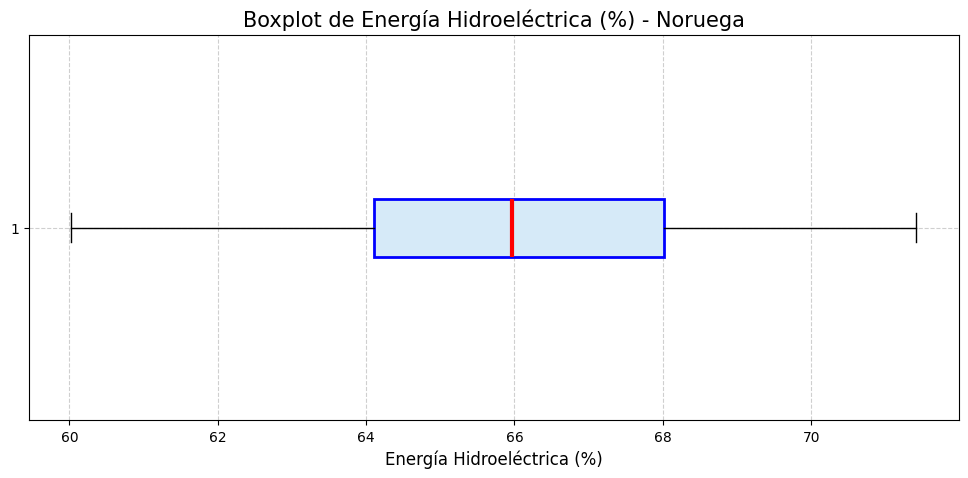

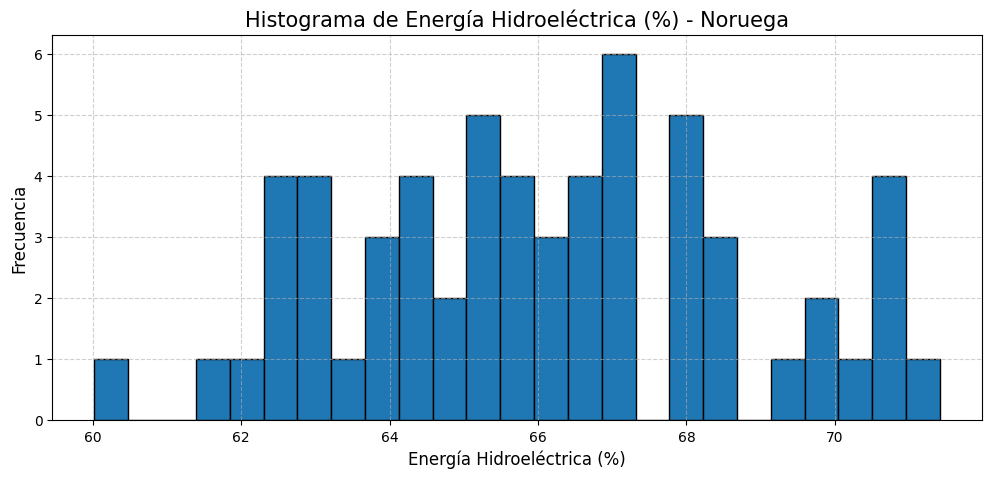

In [13]:
# Analizamos energía hidroeléctrica de Noruega
analizar_variable(df, "Norway", "Noruega", "Porcentaje_Hidroelectrica", "Energía Hidroeléctrica (%)")

# Noruega - Energía Hidroeléctrica

## El Boxplot muestra una participación hidroeléctrica relativamente estable, concentrada principalmente entre 64 % y 68 %, sin valores atípicos y el histograma confirma esta concentración y muestra pocos registros hacia los extremos. Esto indica un comportamiento estable de la energía hidroeléctrica durante el período analizado.

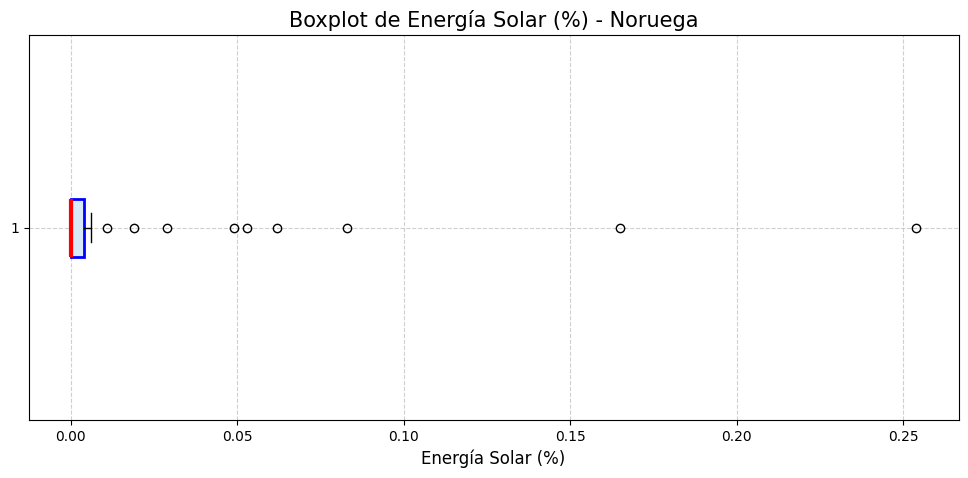

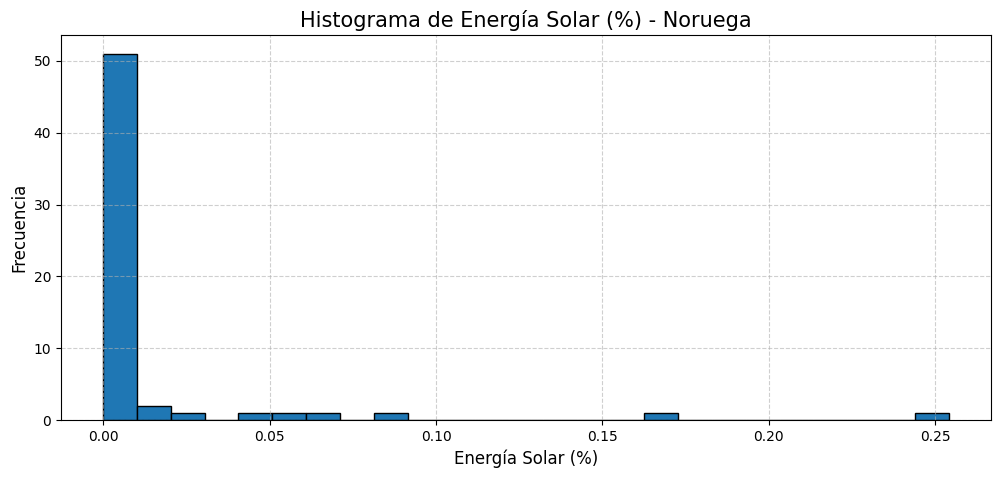

In [14]:
# Analizamos energía solar de Noruega
analizar_variable(df, "Norway", "Noruega", "Porcentaje_Solar", "Energía Solar (%)")

# Noruega - Energía Solar

## El Boxplot muestra varios valores atípicos de participación solar por encima de los valores habituales y el histograma confirma que la mayoría de los registros se concentra cerca del 0 %, mientras que existen pocos registros con valores más elevados. Esto indica una participación solar históricamente baja.

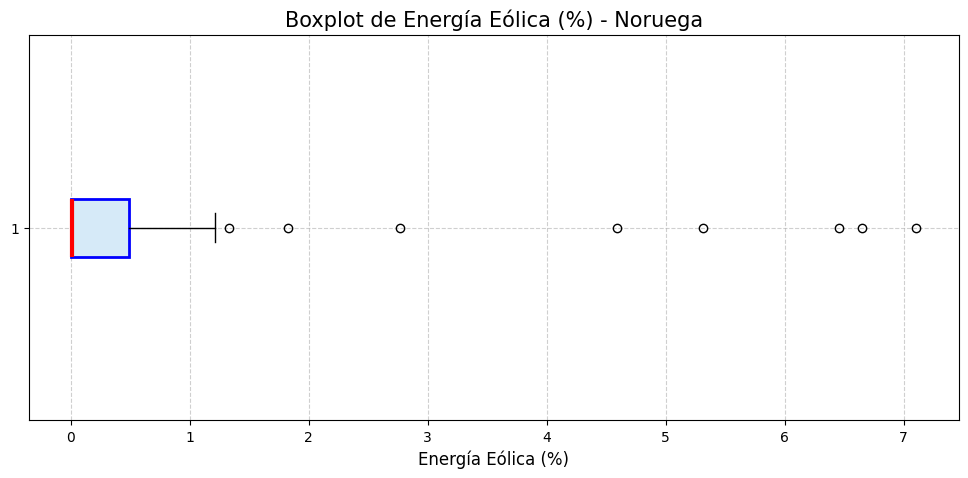

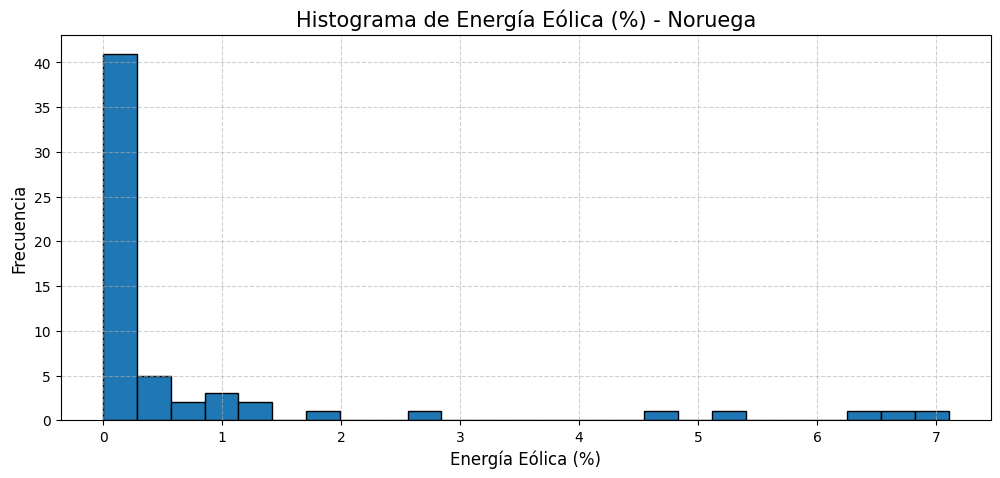

In [15]:
# Analizamos energía eólica de Noruega
analizar_variable(df, "Norway", "Noruega", "Porcentaje_Eolica", "Energía Eólica (%)")

# Noruega - Energía Eólica

## El Boxplot muestra varios valores atípicos de participación eólica por encima del 1 % y el histograma confirma que la mayoría de los registros se concentra cerca del 0 %, mientras que los valores más altos aparecen con menor frecuencia. Al igual que la solar, la eólica también muestra una baja participación.

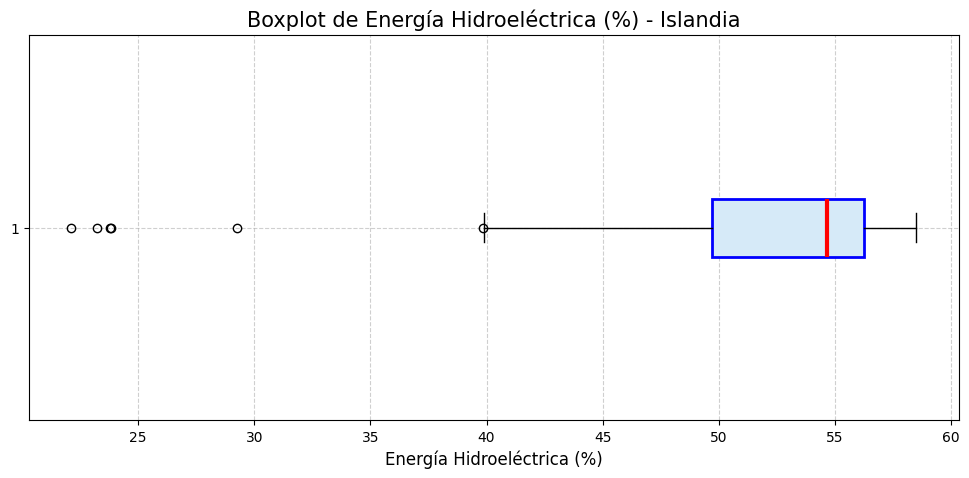

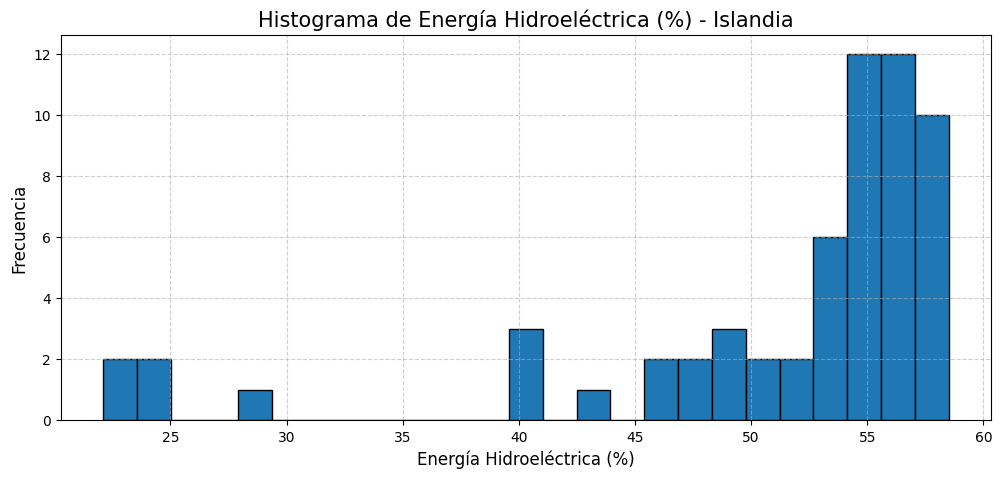

In [16]:
# Analizamos energía hidroeléctrica de Islandia
analizar_variable(df, "Iceland", "Islandia", "Porcentaje_Hidroelectrica", "Energía Hidroeléctrica (%)")

# Islandia - Energía Hidroeléctrica

## El Boxplot muestra varios valores atípicos de participación hidroeléctrica por debajo del 30 % y el histograma confirma que estos valores son poco frecuentes, mientras que la mayoría de los registros se concentra entre aproximadamente 50 % y 58 %. Esto muestra que los valores bajos son casos poco habituales dentro del período analizado.

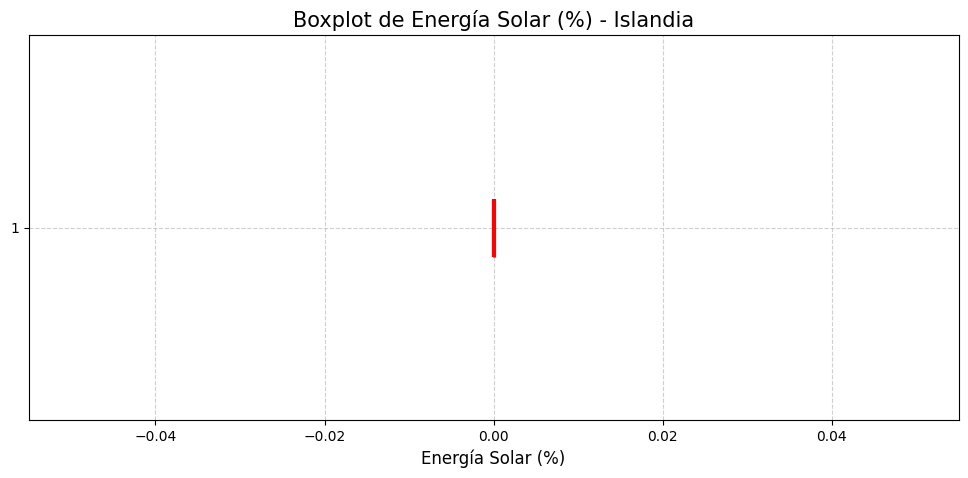

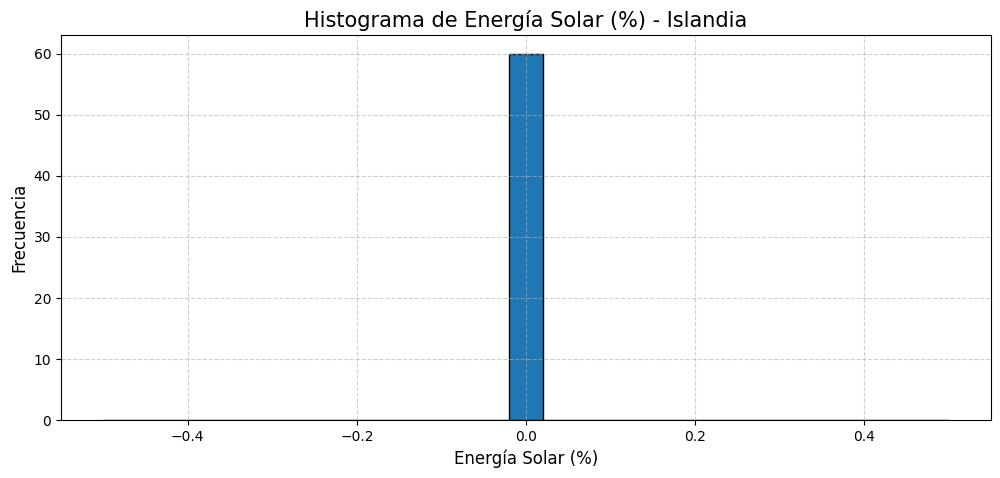

In [17]:
# Analizamos energía solar de Islandia
analizar_variable(df, "Iceland", "Islandia", "Porcentaje_Solar", "Energía Solar (%)")

# Islandia - Energía solar
## El Boxplot muestra que todos los valores de participación solar se encuentran en 0 %, sin variación ni valores atípicos y el histograma confirma que todos los registros se concentran en ese mismo valor. Esto indica que la energía solar no presenta participación registrada en Islandia durante el período analizado.
# Esto además es un resultado interesante: Islandia fue seleccionada entre los países con alta participación renovable, pero claramente esa participación no proviene de la energía solar. Los siguientes gráficos nos ayudarán a ver de qué fuente proviene

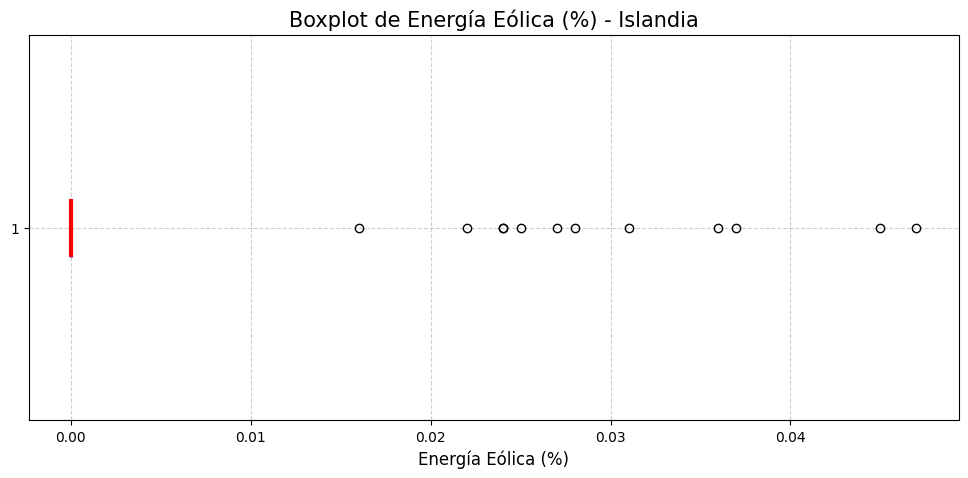

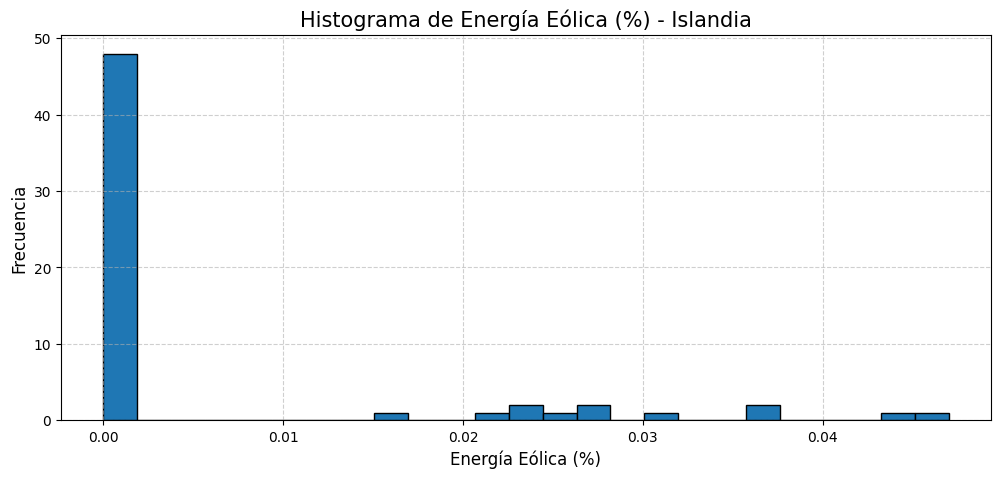

In [18]:
# Analizamos energía eólica de Islandia
analizar_variable(df, "Iceland", "Islandia", "Porcentaje_Eolica", "Energía Eólica (%)")

#Islandia - Energía Eólica

## El Boxplot muestra varios valores atípicos de participación eólica, mientras que la mayoría de los registros se concentra cerca del 0 % y el histograma confirma que los valores superiores son poco frecuentes. Esto indica que la energía eólica tuvo una participación históricamente muy baja en Islandia.

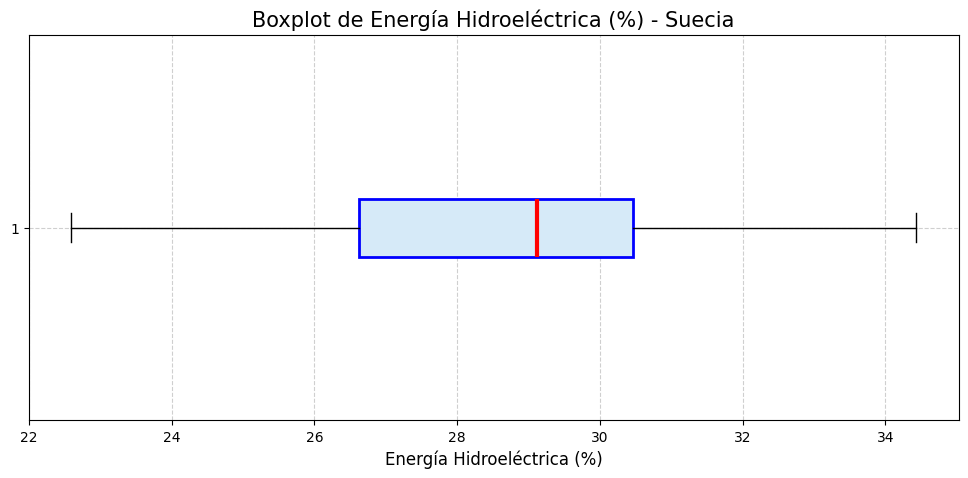

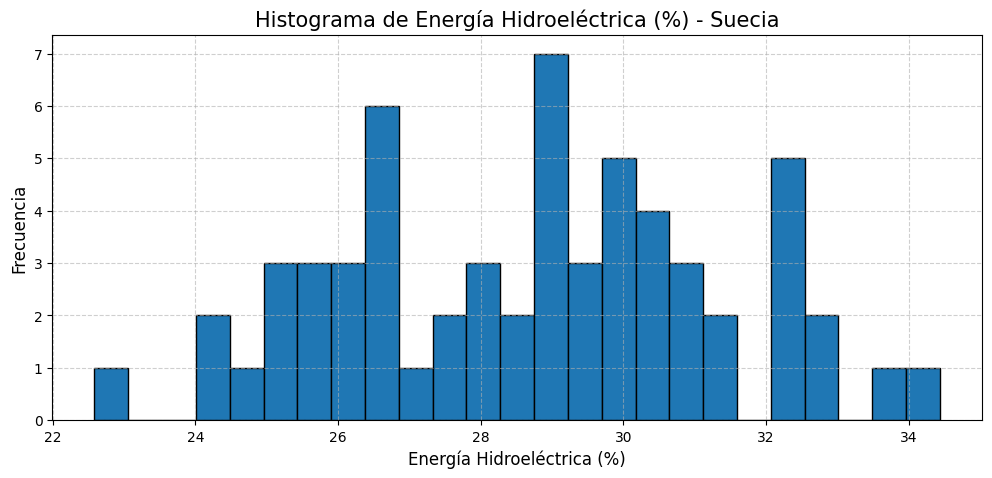

In [19]:
# Analizamos energía hidroeléctrica de Suecia
analizar_variable(df, "Sweden", "Suecia", "Porcentaje_Hidroelectrica", "Energía Hidroeléctrica (%)")

# Suecia - Energía Hidroeléctrica

## El Boxplot muestra que la participación hidroeléctrica se mantiene principalmente entre 26 % y 31 %, sin valores atípicos y el histograma confirma una distribución relativamente estable dentro de ese rango. Esto indica que la energía hidroeléctrica mantuvo una participación importante y sin valores extremos durante el período analizado.

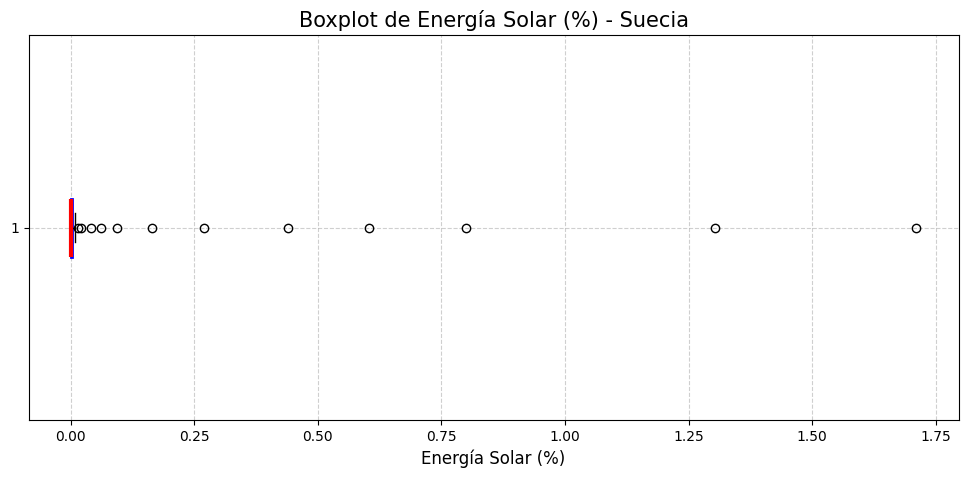

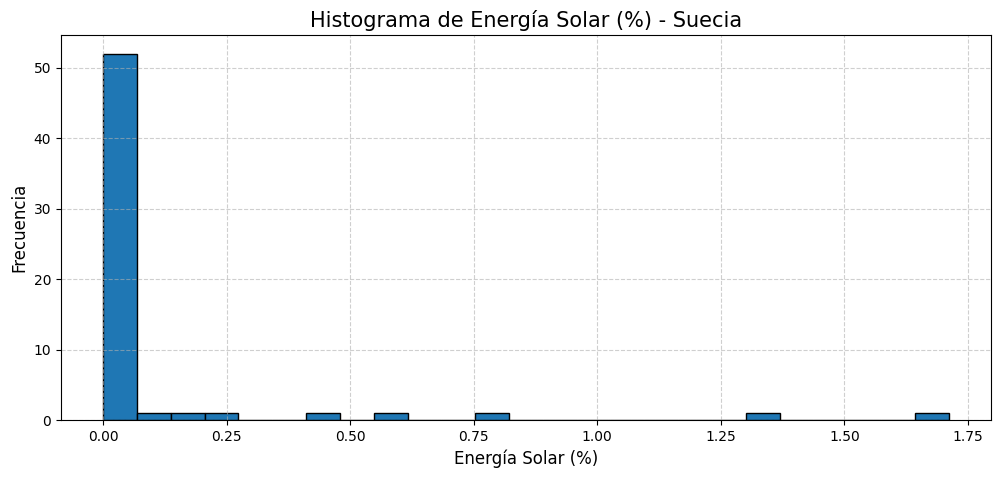

In [20]:
# Analizamos energía solar de Suecia
analizar_variable(df, "Sweden", "Suecia", "Porcentaje_Solar", "Energía Solar (%)")

# Suecia - Energía solar

## El Boxplot muestra varios valores atípicos de participación solar, mientras que la mayoría de los registros se concentra cerca del 0 % y el histograma confirma que los valores más elevados son poco frecuentes, llegando aproximadamente hasta 1,7 %. Esto indica que la energía solar tuvo una participación históricamente baja en Suecia.

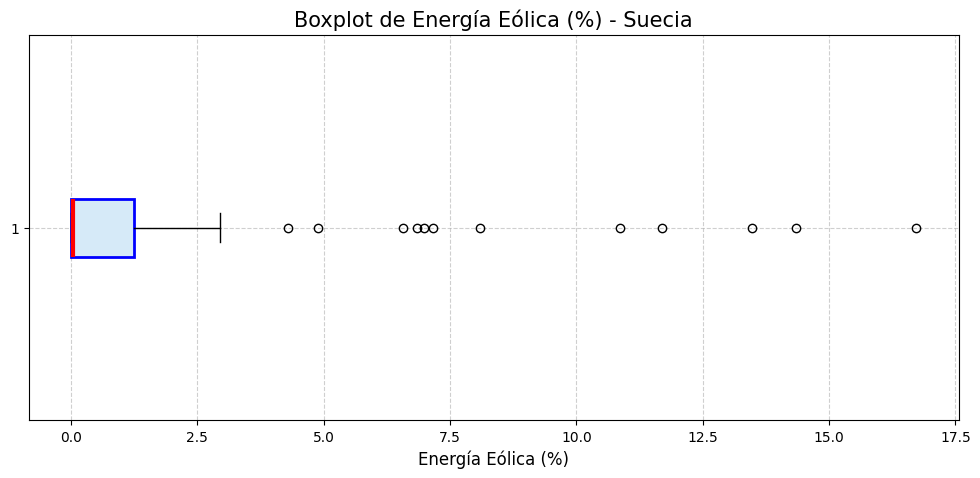

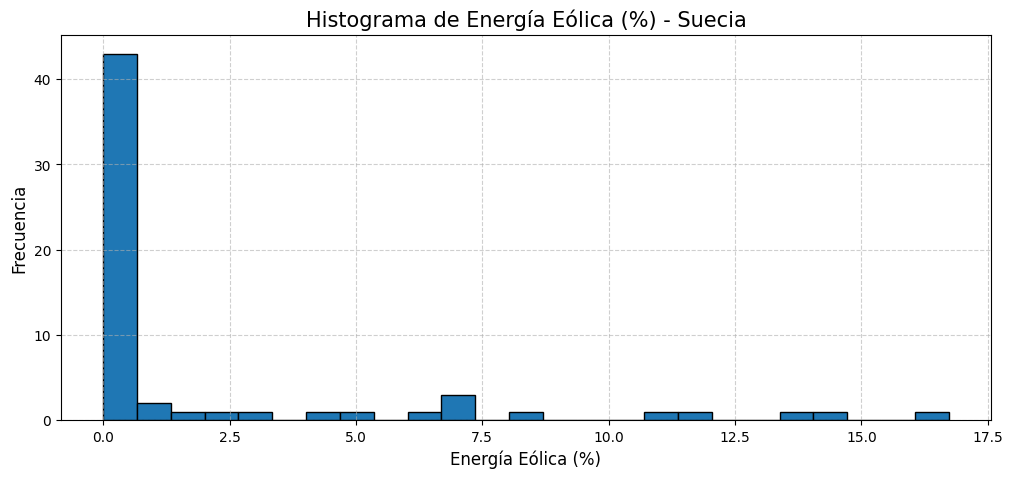

In [21]:
# Analizamos energía eólica de Suecia
analizar_variable(df, "Sweden", "Suecia", "Porcentaje_Eolica", "Energía Eólica (%)")

# Suecia - Energía Eólica
## El Boxplot muestra varios valores atípicos de participación eólica, llegando aproximadamente hasta el 17 % y el histograma confirma que la mayoría de los registros se concentra cerca del 0 %, mientras que los valores más elevados son menos frecuentes. Esto muestra una gran diferencia entre los valores históricos bajos y algunos registros con una participación eólica mucho mayor.

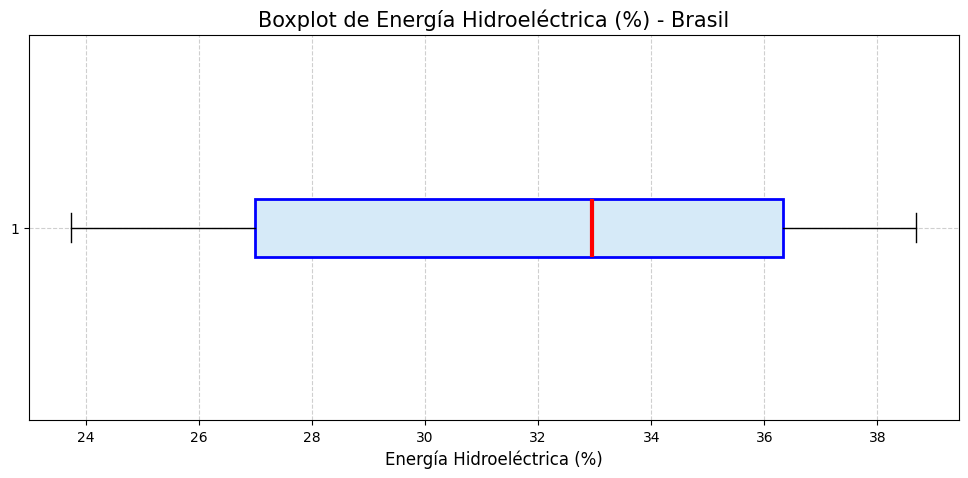

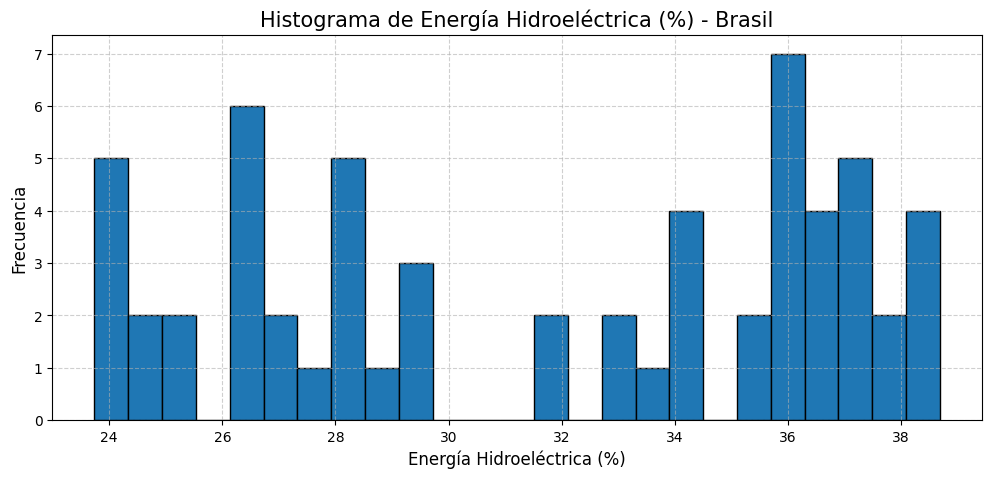

In [22]:
# Analizamos energía hidroeléctrica de Brasil
analizar_variable(df, "Brazil", "Brasil", "Porcentaje_Hidroelectrica", "Energía Hidroeléctrica (%)")

# Brasil - Energía Hidroeléctrica

## El Boxplot muestra una participación hidroeléctrica variable, aproximadamente entre 24 % y 39 %, sin valores atípicos y el histograma confirma que los registros se distribuyen dentro de ese rango, con una mayor concentración alrededor del 35 % al 38 %. Esto indica una participación hidroeléctrica importante, aunque con variaciones entre los registros.

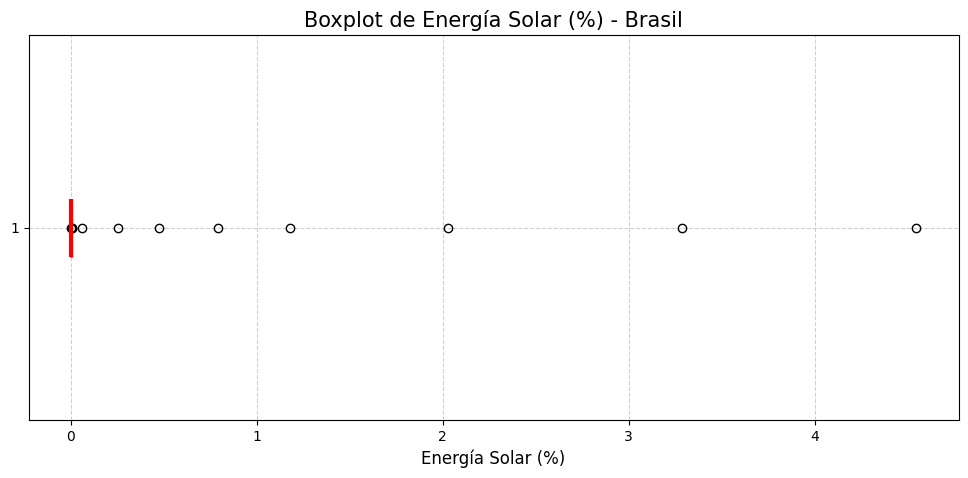

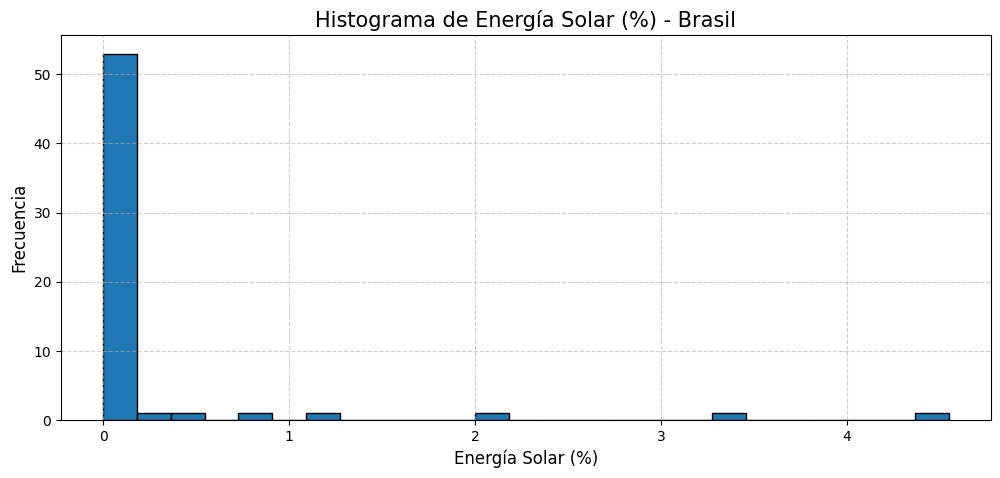

In [23]:
# Analizamos energía solar de Brasil
analizar_variable(df, "Brazil", "Brasil", "Porcentaje_Solar", "Energía Solar (%)")

# Brasil - Energía solar
## El Boxplot muestra varios valores atípicos de participación solar, mientras que la mayoría de los registros se concentra cerca del 0 % y el histograma confirma que los valores más elevados son poco frecuentes, llegando aproximadamente hasta 4,5 %. Esto indica una participación solar históricamente baja, aunque existen algunos registros con valores mayores.

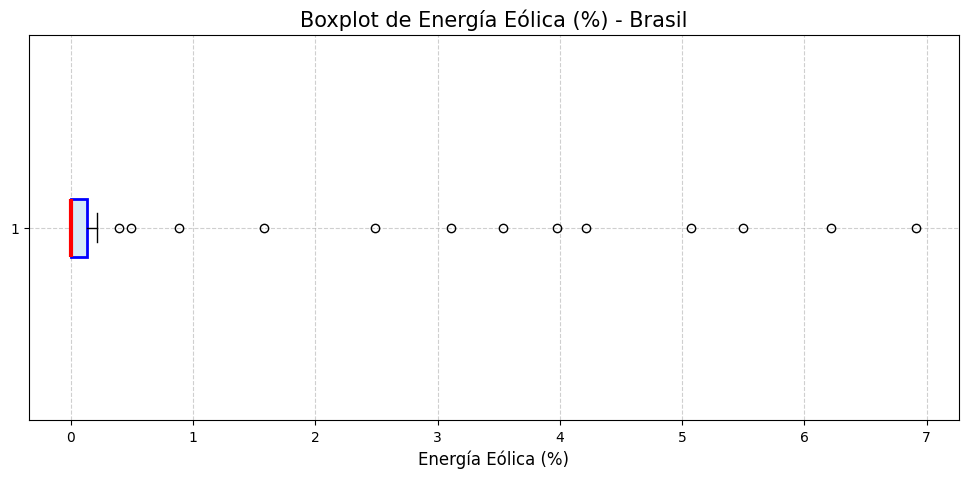

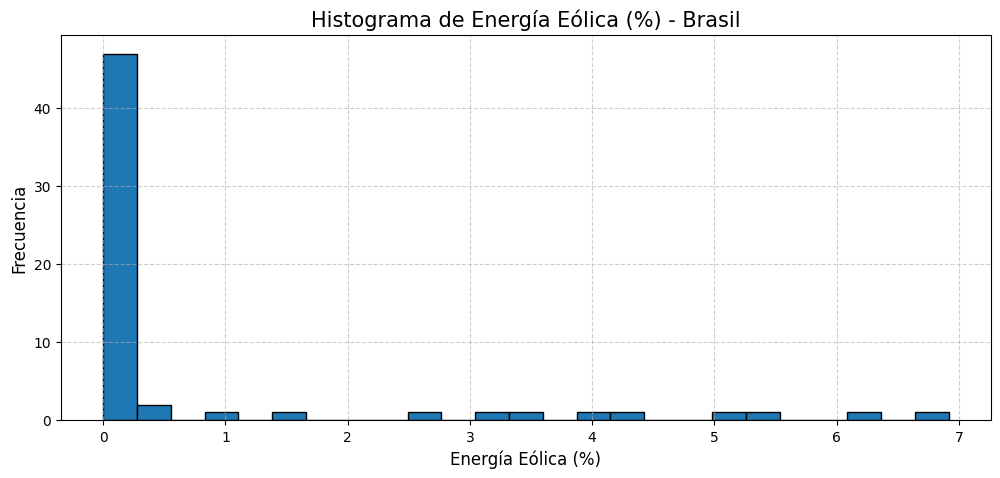

In [24]:
# Analizamos energía eólica de Brasil
analizar_variable(df, "Brazil", "Brasil", "Porcentaje_Eolica", "Energía Eólica (%)")

# Brasil - Energía Eólica

## El Boxplot muestra varios valores atípicos de participación eólica, mientras que la mayoría de los registros se concentra cerca del 0 % y el histograma confirma que los valores más elevados son poco frecuentes, llegando aproximadamente hasta el 7 %. Esto muestra una gran diferencia entre los valores históricos bajos y los registros un poco mas grandes.

# <u><b> CONCLUSIÓN DEL ANÁLISIS DE DISTRIBUCIÓN </b></u>

## Los Boxplots e histogramas muestran diferencias importantes entre las tres fuentes de energía renovable analizadas. La energía hidroeléctrica presenta una participación elevada y relativamente estable en los cuatro países, mientras que la energía solar y eólica muestran muchos registros históricos cercanos a 0 %.

## Estos valores aparecen como atípicos porque se alejan del comportamiento histórico habitual, pero estos gráficos no permiten determinar en qué años ocurrieron. Por este motivo, el siguiente paso será realizar gráficos temporales para observar la evolución de cada fuente.

# <u><b> Análisis de la evolución temporal </b></u>

## Se realizarán cinco gráficos temporales para observar cómo evolucionaron las energías hidroeléctrica, solar y eólica a lo largo de los años en los cuatro países seleccionados y comparar sus resultados con Argentina.

In [25]:
# Creamos una función para analizar la evolución
def analizar_evolucion(df, pais, nombre_pais):

    # Seleccionamos los datos del país
    datos = df[df["Pais"] == pais].copy()

    # Ordenamos los datos por año
    datos = datos.sort_values("Año")

    # Creamos el gráfico
    plt.figure(figsize=(12, 6))

    plt.plot(
        datos["Año"],
        datos["Porcentaje_Hidroelectrica"],
        marker="o",
        label="Hidroeléctrica")

    plt.plot(
        datos["Año"],
        datos["Porcentaje_Solar"],
        marker="o",
        label="Solar")

    plt.plot(
        datos["Año"],
        datos["Porcentaje_Eolica"],
        marker="o",
        label="Eólica")

    plt.title("Evolución de las Energías Renovables - " + nombre_pais, fontsize=15)
    plt.xlabel("Año", fontsize=12)
    plt.ylabel("Participación (%)", fontsize=12)

    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.6)

    plt.show()

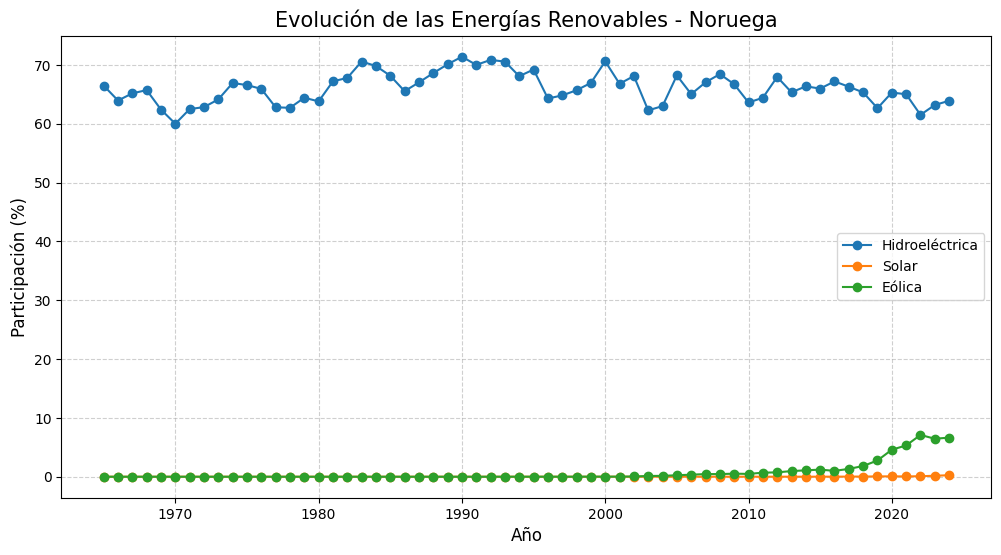

In [26]:
analizar_evolucion(df, "Norway", "Noruega")

# Evolución de las Energías Renovables - Noruega

## La energía hidroeléctrica mantiene una participación alta y relativamente estable durante todo el período. La energía solar permanece cerca del 0 %, mientras que la energía eólica muestra un aumento principalmente en los últimos años, llegando aproximadamente al 7 %.

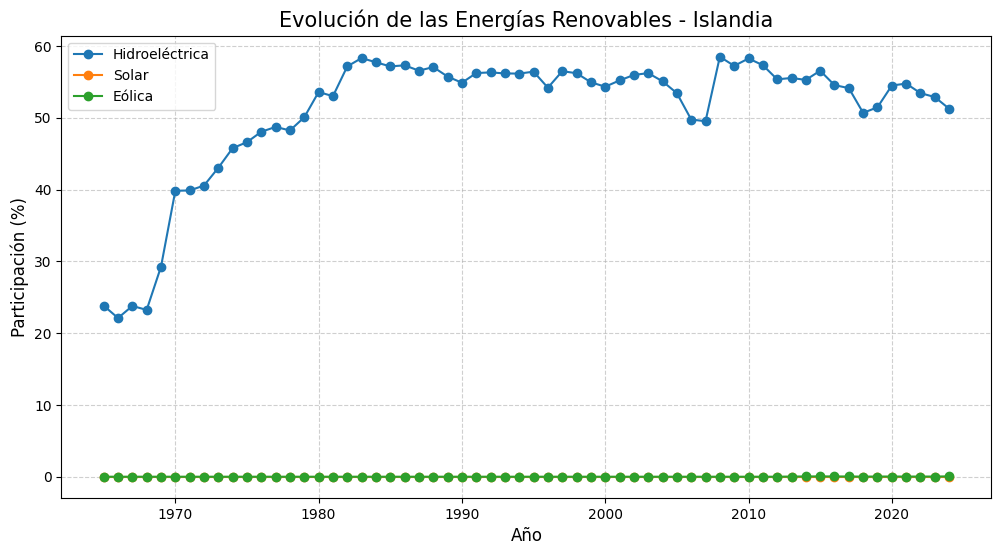

In [27]:
analizar_evolucion(df, "Iceland", "Islandia")

# Evolución de las Energías Renovables - Islandia

## La energía hidroeléctrica muestra un fuerte crecimiento en los primeros años y luego mantiene una participación elevada, alrededor del 50 % al 58 %. En cambio, la energía solar y eólica permanecen prácticamente en 0 % durante todo el período analizado.

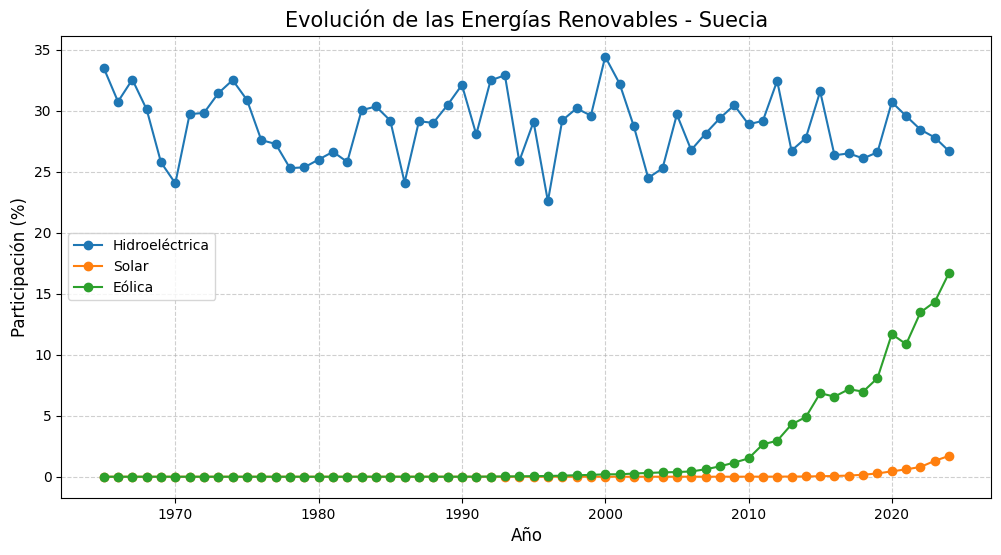

In [28]:
analizar_evolucion(df, "Sweden", "Suecia")

# Evolución de las Energías Renovables - Suecia

## La energía hidroeléctrica mantiene una participación elevada durante todo el período, aunque presenta variaciones. La energía eólica muestra un fuerte crecimiento a partir del 2010, llegando cerca del 17 % en los últimos años. La energía solar también comienza a crecer recientemente, pero mantiene una participación mucho menor.

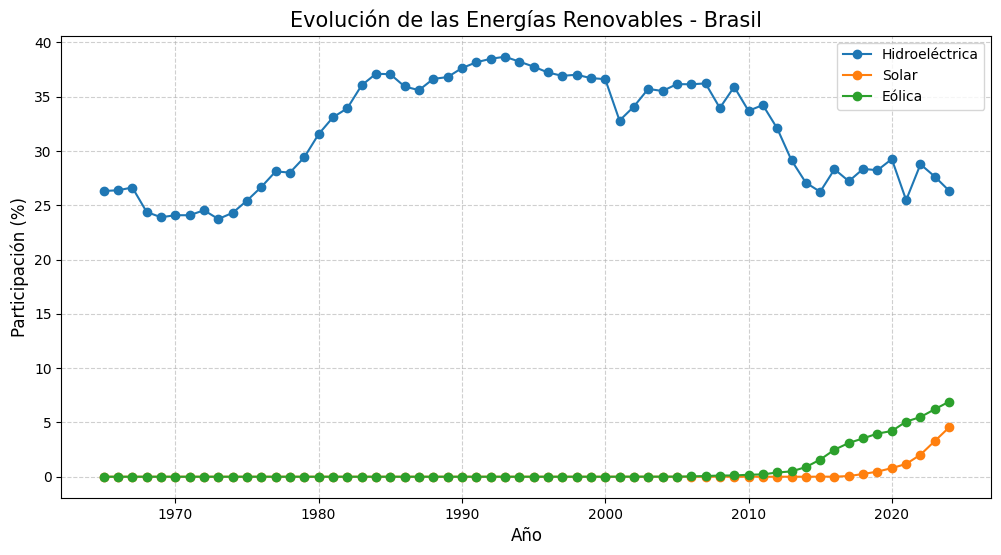

In [29]:
analizar_evolucion(df, "Brazil", "Brasil")

# Evolución de las Energías Renovables - Brasil

## La energía hidroeléctrica presenta una participación históricamente alta, aunque muestra una disminución en los últimos años. En cambio, la energía eólica y solar muestran un crecimiento reciente, alcanzando aproximadamente 7 % y 4,5 % respectivamente. Esto muestra una mayor participación de nuevas fuentes renovables en los últimos años.

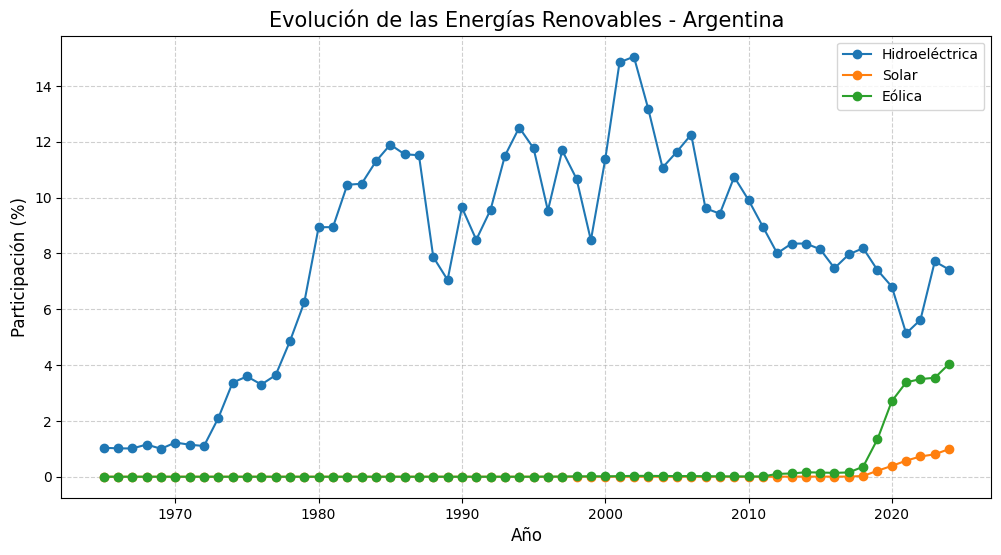

In [30]:
analizar_evolucion(df, "Argentina", "Argentina")

# Evolución de las Energías Renovables - Argentina

## La energía hidroeléctrica fue históricamente la fuente renovable con mayor participación, aunque muestra una disminución en los últimos años. En cambio, la energía eólica y solar presentan un crecimiento reciente, alcanzando aproximadamente 4 % y 1 % respectivamente.

# <u><b> CONCLUSIÓN DEL ANÁLISIS TEMPORAL </b></u>
## Los gráficos muestran que la energía hidroeléctrica tiene una participación histórica importante en los países seleccionados, mientras que la energía solar y eólica presentan su mayor crecimiento en los últimos años.

## Al comparar con Argentina se observa un comportamiento similar: disminuye la participación hidroeléctrica mientras comienzan a crecer la energía eólica y solar. Sin embargo, su participación renovable todavía se encuentra por debajo de los niveles observados en los cuatro países seleccionados.

# Análisis de correlación

## Se analizará la correlación entre las distintas fuentes de energía para identificar si existe alguna relación entre la participación de los combustibles fósiles y las energías renovables.

In [31]:
# Creamos la matriz de correlación
# Seleccionamos las variables que queremos analizar
variables = [
    "Porcentaje_Fosil",
    "Porcentaje_Hidroelectrica",
    "Porcentaje_Solar",
    "Porcentaje_Eolica",
    "Porcentaje_Otras_Renovables"]

# Calculamos la matriz de correlación
correlacion = df[variables].corr()

# Mostramos los resultados
display(correlacion)

,Porcentaje_Fosil,Porcentaje_Hidroelectrica,Porcentaje_Solar,Porcentaje_Eolica,Porcentaje_Otras_Renovables
Porcentaje_Fosil,1.000000,-0.845431,-0.138240,-0.226574,-0.487912
Porcentaje_Hidroelectrica,-0.845431,1.000000,-0.053945,-0.017725,0.304383
Porcentaje_Solar,-0.138240,-0.053945,1.000000,0.476134,0.151468
Porcentaje_Eolica,-0.226574,-0.017725,0.476134,1.000000,0.306221
Porcentaje_Otras_Renovables,-0.487912,0.304383,0.151468,0.306221,1.000000


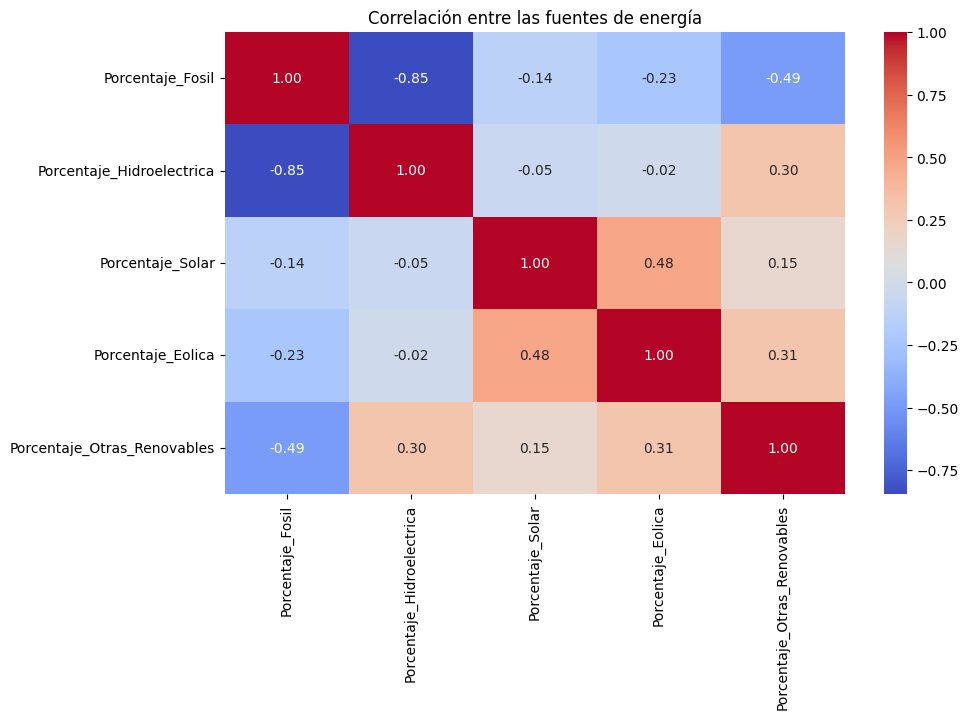

In [32]:
plt.figure(figsize=(10, 6))

sns.heatmap(correlacion, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlación entre las fuentes de energía")
plt.show()

# <u><b> Análisis de correlación </b></u>

## El mapa de calor muestra una fuerte correlación negativa (-0,85) entre la energía hidroeléctrica y los combustibles fósiles. Esto indica que una mayor participación hidroeléctrica se encuentra asociada con una menor participación de energía fósil.

## La energía solar y eólica también presentan correlaciones negativas con los combustibles fósiles, aunque mucho más débiles.

#<u><b> PARTE 4: MODELADO DE MINERÍA </b></u>
---
---
# <u><b> Modelado Predictivo </b></u>

## A partir del análisis de correlación se observó una fuerte relación negativa (-0,85) entre la participación de energía hidroeléctrica y los combustibles fósiles.

## Por este motivo, se realizará una regresión lineal simple utilizando la participación hidroeléctrica para predecir la participación de combustibles fósiles.

In [33]:
# Importamos las herramientas necesarias
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Definimos las variables
X = df[["Porcentaje_Hidroelectrica"]]
y = df["Porcentaje_Fosil"]

# Separamos los datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split (X, y, test_size=0.20, random_state=42)

# Mostramos la cantidad de datos utilizados
print("Datos de entrenamiento:", len(X_train))
print("Datos de prueba:", len(X_test))

# Creamos el modelo de regresión lineal
modelo = LinearRegression()

# Entrenamos el modelo
modelo.fit(X_train, y_train)

Datos de entrenamiento: 3567
Datos de prueba: 892


LinearRegression()

In [34]:
# Realizamos las predicciones
y_pred = modelo.predict(X_test)

# Mostramos algunos resultados
resultados = pd.DataFrame({"Valor real": y_test, "Valor predicho": y_pred})

display(resultados.head(10))

,Valor real,Valor predicho
1384,97.091,92.404441
9075,99.052,94.692761
9837,94.138,91.971257
14170,85.736,95.128074
15357,92.966,94.640609
8633,99.924,95.500592
15787,89.484,84.328267
14334,88.525,83.287347
12518,94.076,94.935430
5513,85.129,79.672866


# <u><b> Evaluación del modelo con R²</b></u>

## Una vez realizadas las predicciones, evaluamos el rendimiento del modelo utilizando los 892 datos que fueron reservados para la prueba.

In [35]:
# Importamos la herramienta para evaluar el modelo
from sklearn.metrics import r2_score

# Calculamos R²
r2 = r2_score(y_test, y_pred)

print("R² del modelo:", round(r2, 2))

R² del modelo: 0.71


# <u><b> Resultado de la evaluación </b></u>

## El modelo obtuvo un R² de 0,71. Esto indica que la participación de energía hidroeléctrica permite explicar aproximadamente el 71 % de la variación observada en la participación de combustibles fósiles.

##El resultado muestra que existe una relación lineal importante entre ambas variables, aunque el modelo no explica completamente el comportamiento de los combustibles fósiles.

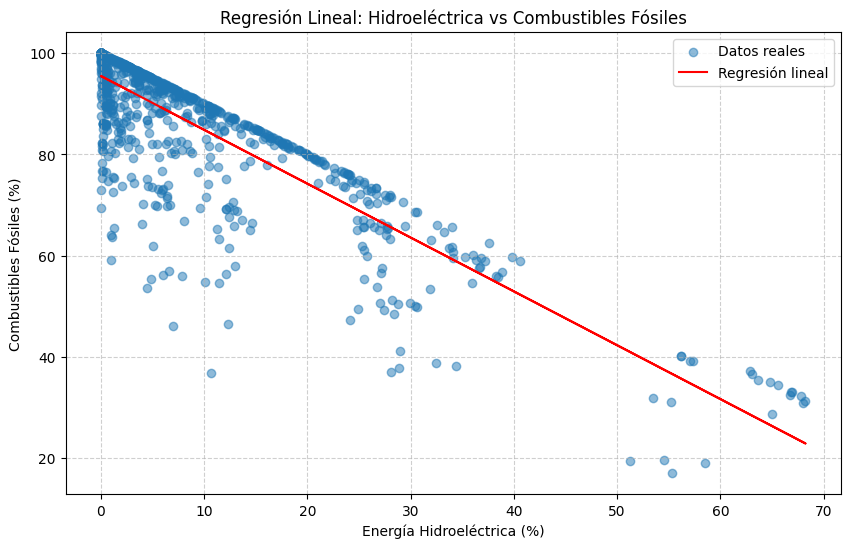

In [36]:
# Graficamos los datos reales
plt.figure(figsize=(10, 6))

plt.scatter(
    X_test["Porcentaje_Hidroelectrica"], y_test, alpha=0.5, label="Datos reales")

# Graficamos la recta de regresión
plt.plot(
    X_test["Porcentaje_Hidroelectrica"],
    y_pred,
    color="red",
    label="Regresión lineal")

plt.title("Regresión Lineal: Hidroeléctrica vs Combustibles Fósiles")
plt.xlabel("Energía Hidroeléctrica (%)")
plt.ylabel("Combustibles Fósiles (%)")

plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)

plt.show()

# <u><b> Análisis de la regresión lineal </b></u>

## El gráfico muestra una relación negativa entre la participación hidroeléctrica y los combustibles fósiles. A medida que aumenta la participación de energía hidroeléctrica, tiende a disminuir la participación de combustibles fósiles.

## La dispersión de algunos puntos respecto de la recta indica que existen otros factores que también influyen en la participación de combustibles fósiles, lo cual es coherente con el R² obtenido de 0,71.

# <u><b> CONCLUSIÓN FINAL </b></u>
---
---

## A partir del análisis realizado se observaron diferencias importantes en la participación y evolución de las energías renovables.

## La energía hidroeléctrica presenta una participación histórica elevada y relativamente estable en los países seleccionados. En cambio, la energía solar y eólica tuvieron durante muchos años una participación muy baja, pero los gráficos temporales permitieron comprobar que algunos de los valores altos detectados en los Boxplots corresponden a un crecimiento ocurrido principalmente en los últimos años.

## El análisis de correlación mostró una fuerte relación negativa (-0,85) entre la participación hidroeléctrica y los combustibles fósiles, indicando que una mayor participación hidroeléctrica se encuentra asociada con una menor participación de fuentes fósiles.

## Finalmente, el modelo de regresión lineal obtuvo un R² de 0,71, lo que indica que la participación hidroeléctrica permite explicar aproximadamente el 71 % de la variación observada en la participación de combustibles fósiles.

## En conclusión, los datos muestran que la energía hidroeléctrica es actualmente la alternativa renovable más solida entre las analizadas y presenta una fuerte relación inversa con los combustibles fósiles. Por este motivo, sería la principal opción a considerar para continuar con su desarrollo. En cambio, la energía solar y eólica muestran un crecimiento reciente, pero todavía presentan una participación menor y se encuentran en una etapa de desarrollo.


# <u><b> PARTE 5: ENVÍO AUTOMÁTICO DE LA CONCLUSIÓN </b></u>
---
---
## Como paso final del análisis, se agrega una función que permite enviar por correo electrónico los informes de las 3 energías analizadas y la conclusión final.

In [37]:
# Instalamos yagmail
# uTILIZO -q para que no se visualice la instalación
!pip install -q yagmail

In [38]:
# Importamos yagmail
import yagmail

def enviar_conclusion():

    print("Seleccione una opción:")
    print("1 - Enviar informe de Energía Hidroeléctrica")
    print("2 - Enviar informe de Energía Solar")
    print("3 - Enviar informe de Energía Eólica")
    print("4 - Recomendar una energía para avanzar con su implementación")

    opcion = input("Ingrese una opción: ")

    # OPCIÓN 1 - INFORME HIDROELÉCTRICA
    if opcion == "1":

        energia = "Energía Hidroeléctrica"

        conclusion = """
La energía hidroeléctrica se destaca como una fuente renovable con una participación histórica importante en los países analizados.

Los resultados muestran que los países con mayor participación hidroeléctrica tienden a presentar una menor dependencia de los combustibles fósiles. Esta relación fue respaldada tanto por el análisis de correlación como por el modelo predictivo desarrollado.

Por este motivo, la energía hidroeléctrica aparece como una alternativa relevante para considerar dentro de una estrategia orientada a reducir progresivamente la participación de combustibles fósiles en la matriz energética..
"""

        asunto = "Informe energético - Energía Hidroeléctrica"


    # OPCIÓN 2 - INFORME SOLAR
    elif opcion == "2":

        energia = "Energía Solar"

        conclusion = """
La energía solar presentó históricamente una participación baja en los
países analizados.

Sin embargo, los gráficos temporales permitieron observar un crecimiento
de esta fuente principalmente durante los últimos años, especialmente
en países como Brasil y Suecia.
"""

        asunto = "Informe energético - Energía Solar"


    # OPCIÓN 3 - INFORME EÓLICA
    elif opcion == "3":

        energia = "Energía Eólica"

        conclusion = """
La energía eólica presentó históricamente una participación baja, pero
los gráficos temporales muestran un crecimiento importante durante los
últimos años.

Este crecimiento se observa especialmente en Suecia, Brasil y Noruega.
En Argentina también se observa un crecimiento reciente de esta fuente.
"""

        asunto = "Informe energético - Energía Eólica"


    # OPCIÓN 4 - RECOMENDAR UNA ENERGÍA
    elif opcion == "4":

        print("")
        print("Seleccione la energía que desea recomendar:")
        print("1 - Energía Hidroeléctrica")
        print("2 - Energía Solar")
        print("3 - Energía Eólica")

        recomendacion = input("Ingrese una opción: ")

        if recomendacion == "1":
            energia = "Energía Hidroeléctrica"

        elif recomendacion == "2":
            energia = "Energía Solar"

        elif recomendacion == "3":
            energia = "Energía Eólica"

        else:
            print("La opción ingresada no es válida.")
            return


        conclusion = """
A partir de los resultados obtenidos en el análisis realizado,
se recomienda avanzar con la implementación de:

""" + energia + """

Esta recomendación se realiza a partir de los resultados obtenidos
durante el análisis exploratorio de los datos.

Se propone iniciar una nueva etapa de análisis, incorporando datos técnicos,
topográficos y de factibilidad, con el objetivo de evaluar las condiciones
necesarias para su implementación.
"""

        asunto = "Recomendación energética - " + energia


    # OPCIÓN INCORRECTA
    else:
        print("La opción ingresada no es válida.")
        return


    # SOLICITAMOS EL CORREO
    mail_ministro = input("Ingrese el correo del Ministro de Energía: ")


    # DATOS DEL CORREO
    mail_analista = "fundamento1701@gmail.com"
    contraseña = "hgyrojghefxsvadx"


    # ARMAMOS EL MENSAJE
    mensaje = """
Estimado Ministro de Energía:

A partir del análisis realizado sobre las distintas fuentes de energía,
se presenta el siguiente informe:

""" + conclusion + """

Saludos.

Damián Coria
"""


    # CONECTAMOS CON GMAIL
    yag = yagmail.SMTP( user=mail_analista, password=contraseña)


    # ENVIAMOS EL CORREO
    yag.send(to=mail_ministro, subject=asunto, contents=mensaje)


    print("")
    print("Correo enviado correctamente.")

In [ ]:
#Llamamos a la fumcion
enviar_conclusion()

Seleccione una opción:
1 - Enviar informe de Energía Hidroeléctrica
2 - Enviar informe de Energía Solar
3 - Enviar informe de Energía Eólica
4 - Recomendar una energía para avanzar con su implementación
